In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
df = pd.read_csv(r'C:\Users\Yashmi\Desktop\youtube_project\USvideos.csv', encoding='latin-1')
with open(r'C:\Users\Yashmi\Desktop\youtube_project\US_category_id.json') as f: 
    categories = json.load(f)
cat_dict = {int(item['id']) : item ['snippet']['title']
           for item in categories['items']}
df['category_name'] = df['category_id'].map(cat_dict)

print(f"Dataset loaded.. Shape: {df.shape}")
print(f"Colums: {list(df.columns)}")

Dataset loaded.. Shape: (40949, 17)
Colums: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'category_name']


In [5]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


In [6]:
#check the basic info bout the dataset 
print("Shape:", df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Basic Statistics ---")
df[['views', 'likes', 'dislikes', 'comment_count']].describe()

Shape: (40949, 17)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14

,views,likes,dislikes,comment_count
count,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


In [8]:
#remove duplicate rows 
df=df.drop_duplicates(subset='video_id')
print(f"After removing duplicates: {df.shape[0]} videos")

#extrct useful features form publish_time
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day'] = df['publish_time'].dt.day_name()

#count how many yags each video has
df['tag_count'] = df['tags'].apply(lambda x: len(x.split('|')) if x != '[none]' else 0)

print(f"New columns added: publish_hour, publish_day, tag_count")
df[['title', 'views', 'publish_hour', 'publish_day', 'tag_count']].head()

After removing duplicates: 6351 videos
New columns added: publish_hour, publish_day, tag_count


,title,views,publish_hour,publish_day,tag_count
0,WE WANT TO TALK ABOUT OUR MARRIAGE,748374,17,Monday,1
1,The Trump Presidency: Last Week Tonight with J...,2418783,7,Monday,4
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",3191434,19,Sunday,23
3,Nickelback Lyrics: Real or Fake?,343168,11,Monday,27
4,I Dare You: GOING BALD!?,2095731,18,Sunday,14


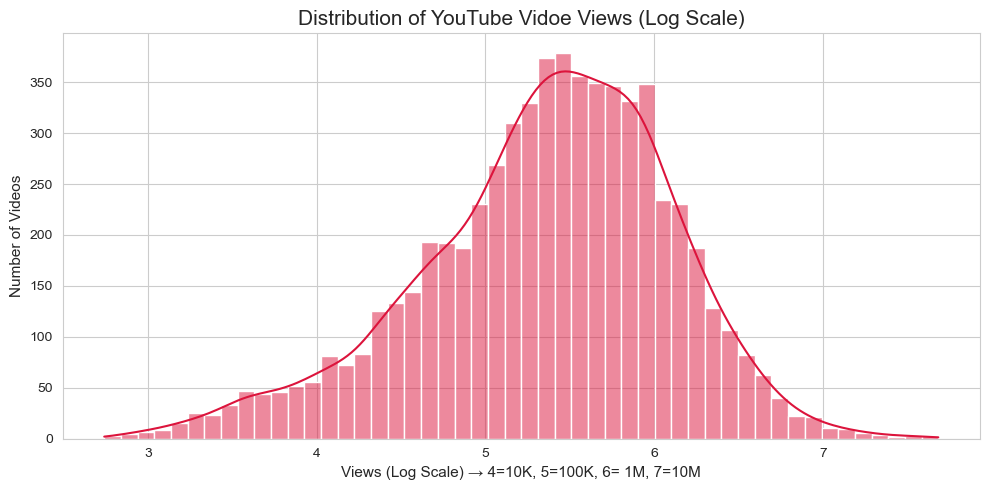

In [9]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

#plot the distribution of views
sns.histplot(np.log10(df['views']), bins=50, color='crimson', kde=True)

plt.title('Distribution of YouTube Vidoe Views (Log Scale)', fontsize=15)
plt.xlabel('Views (Log Scale) → 4=10K, 5=100K, 6= 1M, 7=10M', fontsize=11)
plt.ylabel('Number of Videos', fontsize=11)
plt.tight_layout()
plt.show()

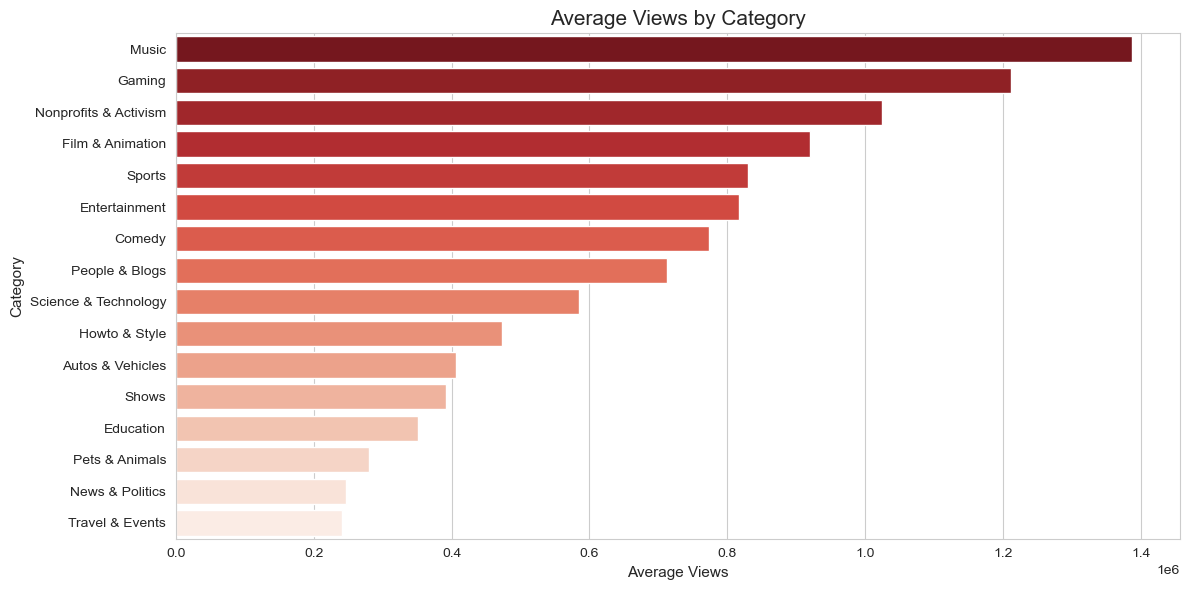

In [11]:
plt.figure(figsize=(12,6))

#calculate average views per category and sort
category_views = df.groupby('category_name') ['views'].mean().sort_values(ascending=False)

#Draw bar chart
sns.barplot(x=category_views.values, y=category_views.index, palette='Reds_r')

plt.title('Average Views by Category', fontsize=15)
plt.xlabel('Average Views', fontsize=11)
plt.ylabel('Category', fontsize=11)
plt.tight_layout()
plt.show()

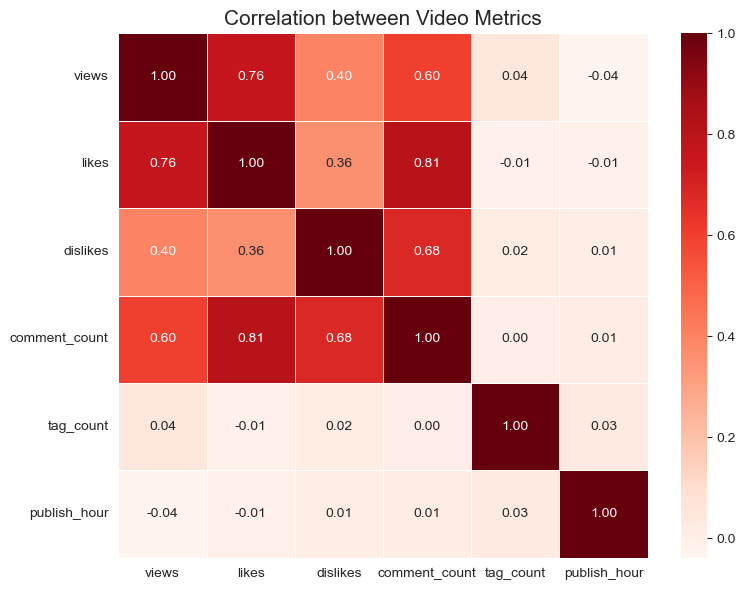

In [13]:
plt.figure(figsize=(8,6))

corr_cols = ['views', 'likes', 'dislikes', 'comment_count', 'tag_count', 'publish_hour']

#calculate correlation between all these columns
correlation = df[corr_cols].corr()

#draw the heatmap
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5)

plt.title('Correlation between Video Metrics', fontsize=15)
plt.tight_layout()
plt.show()

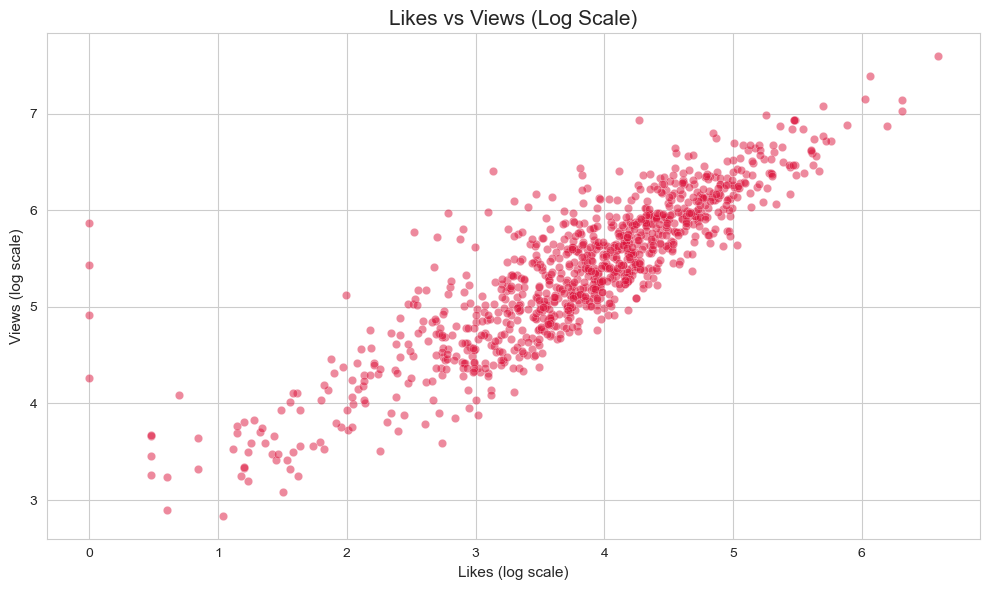

In [14]:
plt.figure(figsize=(10,6))

#plot likes vs views (sample 1000 points)
sample = df.sample(1000, random_state=42)

plt.scatter(np.log10(sample['likes'] + 1),
            np.log10(sample['views'] + 1),
            alpha=0.5, color='crimson', edgecolors='white', linewidth=0.3)

plt.title('Likes vs Views (Log Scale)', fontsize=15)
plt.xlabel('Likes (log scale)', fontsize=11)
plt.ylabel('Views (log scale)', fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn. ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

#choose features(inputs) & targets (what we want to predict)
features = ['likes', 'dislikes', 'comment_count', 'tag_count', 'publish_hour', 'category_id']
target = 'views'

#remove any rows with missing values in these columns
model_df = df[features + [target]].dropna()

X = model_df[features]
Y = model_df[target]

#split data -> 80% for training and 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

#train linear regression model
lr = LinearRegression()
lr.fit(X_train, Y_train)
lr_pred = lr.predict(X_test)

#train random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

#compare results
print("\n--- Model Results ---")
print(f"Linear Regression → R² Score: {r2_score(Y_test, lr_pred):.3f} | MAE: {mean_absolute_error(Y_test, lr_pred):,.0f}")
print(f"Random Forest      → R² Score: {r2_score(Y_test, rf_pred):.3f} | MAE: {mean_absolute_error(Y_test, rf_pred):,.0f}")

Training samples: 5080
Testing samples: 1271

--- Model Results ---
Linear Regression → R² Score: 0.716 | MAE: 422,936
Random Forest      → R² Score: 0.749 | MAE: 324,731


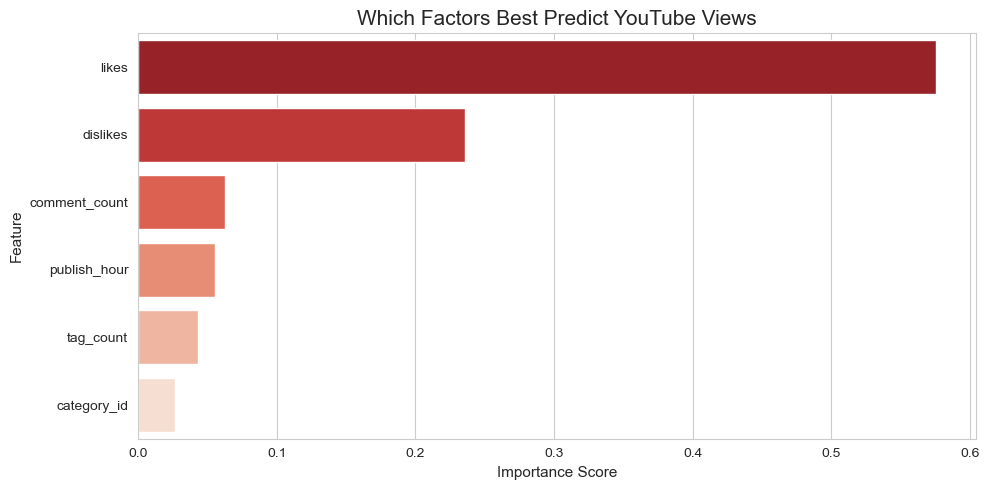

In [23]:
plt.figure(figsize=(10,5))

#get feature importance form random forest
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

sns.barplot(x=importance.values, y=importance.index, palette='Reds_r')

plt.title('Which Factors Best Predict YouTube Views', fontsize=15)
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

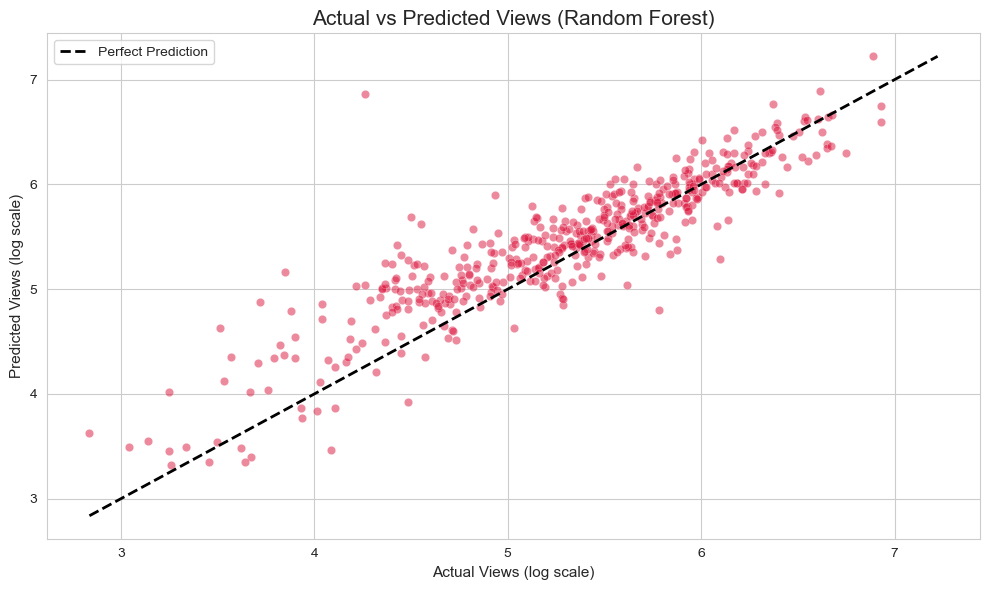


Analysis Complete!
Best Model: Random Forest
R² Score: 0.749
Average Prediction Error: 324,731 views


In [26]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted (sample 500 points)
sample_idx = np.random.choice(len(Y_test), 500, replace=False)
actual = np.array(Y_test)[sample_idx]
predicted = rf_pred[sample_idx]

plt.scatter(np.log10(actual + 1), np.log10(predicted + 1), 
            alpha=0.5, color='crimson', edgecolors='white', linewidth=0.3)

# Draw a perfect prediction line
min_val = min(np.log10(actual + 1).min(), np.log10(predicted + 1).min())
max_val = max(np.log10(actual + 1).max(), np.log10(predicted + 1).max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Views (Random Forest)', fontsize=15)
plt.xlabel('Actual Views (log scale)', fontsize=11)
plt.ylabel('Predicted Views (log scale)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

print("\nAnalysis Complete!")
print(f"Best Model: Random Forest")
print(f"R² Score: {r2_score(Y_test, rf_pred):.3f}")
print(f"Average Prediction Error: {mean_absolute_error(Y_test, rf_pred):,.0f} views")
